In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [2]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [3]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-1.585777,0.068758,-0.077595,-0.235380,1.755828,1
1,1.066326,-1.400929,-0.901323,1.778015,3.052556,0
2,0.880822,0.306329,1.981497,3.367041,-0.418143,1
3,-1.308823,-0.271354,0.097539,1.325619,3.142093,1
4,0.172956,1.634701,-1.448662,-0.652267,0.488193,0


In [4]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [5]:
# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df
     

In [6]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

### Rows sampling

In [11]:
df1 = sample_rows(df,0.2)
df1

,col1,col2,col3,col4,col5,target
19,0.065431,1.008353,-2.195077,-0.927651,1.002485,0
96,-0.210981,0.584974,-1.804930,-1.290103,0.782964,0
6,-1.067869,-1.791508,1.908250,-0.379674,-1.471084,1
85,0.405231,0.847471,-1.808725,-0.846021,1.076678,0
50,3.135515,-1.703529,0.684582,0.257725,3.340886,0
12,-1.361451,-1.659782,0.810286,0.954040,1.628612,1
11,1.864039,0.793874,-1.416974,-1.422903,1.741459,0
57,1.482642,-0.542275,0.143358,-1.439071,1.240504,0
74,0.386817,-1.161764,-0.219148,-0.676064,1.745213,0
16,1.441277,0.657525,-1.821451,-3.902078,1.502114,0


In [12]:
df2 = sample_rows(df,0.2)
df2

,col1,col2,col3,col4,col5,target
78,-0.436051,-0.536839,3.328623,0.676772,-0.700605,1
6,-1.067869,-1.791508,1.908250,-0.379674,-1.471084,1
11,1.864039,0.793874,-1.416974,-1.422903,1.741459,0
53,1.164465,1.735971,-2.311614,0.984407,1.419641,0
93,0.462616,-0.190054,-0.203641,2.599810,-0.739532,1
29,-0.138306,0.939433,-0.703635,2.564168,1.953581,1
96,-0.210981,0.584974,-1.804930,-1.290103,0.782964,0
7,-2.023628,-2.640031,1.553869,0.146688,1.969576,1
52,-0.994377,-1.030317,0.860597,0.601400,0.103934,1
67,1.001983,1.792050,-1.274538,-2.471065,0.404506,0


In [13]:
df3 = sample_rows(df,0.2)
df3

,col1,col2,col3,col4,col5,target
97,-1.300017,-0.061200,1.147153,0.514499,2.089814,1
96,-0.210981,0.584974,-1.804930,-1.290103,0.782964,0
30,0.225545,0.119571,0.001606,-0.636293,0.656386,0
21,1.830850,3.880379,-0.732485,-0.941140,-0.023154,0
87,1.087739,1.532902,3.184514,2.525470,-1.203170,1
68,-0.469357,1.207166,-0.820920,0.666745,-0.279652,0
39,-0.655481,-1.415175,1.769759,1.357000,0.353455,1
0,-1.585777,0.068758,-0.077595,-0.235380,1.755828,1
8,1.046151,1.150989,-0.546808,-2.512012,0.659288,0
41,0.834440,0.504065,-0.794388,-1.900339,1.413884,0


In [14]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [15]:
clf1.fit(df1.iloc[:,0:5],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:5],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:5],df3.iloc[:,-1])

DecisionTreeClassifier()

In [16]:
from sklearn.tree import plot_tree

[Text(0.4, 0.8333333333333334, 'x[0] <= -0.324\ngini = 0.42\nsamples = 20\nvalue = [14, 6]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.6, 0.5, 'x[3] <= 1.774\ngini = 0.219\nsamples = 16\nvalue = [14, 2]'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 14\nvalue = [14, 0]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]')]

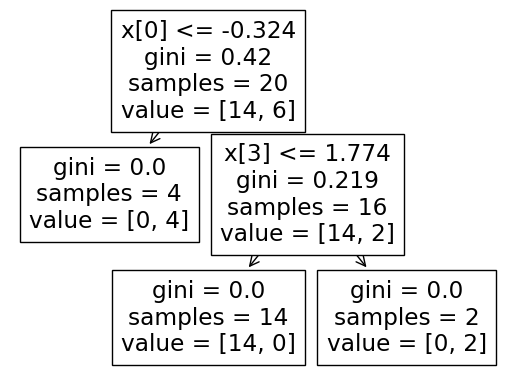

In [17]:
plot_tree(clf1)

[Text(0.4, 0.8333333333333334, 'x[2] <= -0.91\ngini = 0.495\nsamples = 20\nvalue = [11, 9]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 9\nvalue = [9, 0]'),
 Text(0.6, 0.5, 'x[0] <= 1.142\ngini = 0.298\nsamples = 11\nvalue = [2, 9]'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 9\nvalue = [0, 9]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]')]

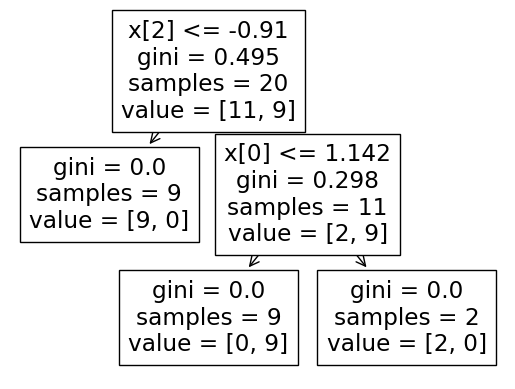

In [18]:
plot_tree(clf2)

[Text(0.6, 0.8333333333333334, 'x[2] <= 0.125\ngini = 0.5\nsamples = 20\nvalue = [10, 10]'),
 Text(0.4, 0.5, 'x[4] <= 1.585\ngini = 0.165\nsamples = 11\nvalue = [10, 1]'),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 10\nvalue = [10, 0]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 9\nvalue = [0, 9]')]

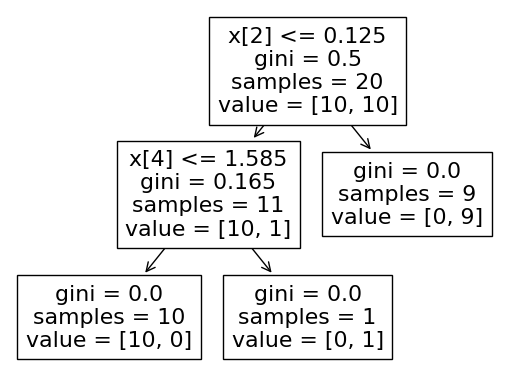

In [19]:
plot_tree(clf3)

In [24]:
clf1.predict(np.array([0.789689,3.133774,-1.808827,-1.569077,-0.648423]).reshape(1,5))

C:\Users\narendra tekale\anaconda3\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [25]:
clf2.predict(np.array([0.789689,3.133774,-1.808827,-1.569077,-0.648423]).reshape(1,5))

C:\Users\narendra tekale\anaconda3\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [26]:
clf3.predict(np.array([0.789689,3.133774,-1.808827,-1.569077,-0.648423]).reshape(1,5))

C:\Users\narendra tekale\anaconda3\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])